# 05 — Cost-Sensitive Threshold Tuning
### Heads-Up | Stage 8: Hyperparameter Optimization (part 5 of 6)

Every model so far has been evaluated at the default 0.5 classification threshold. But our actual business framing says a missed late delivery (false negative) costs more than an unnecessary intervention (false positive), so the threshold should reflect that asymmetry, not an arbitrary midpoint.


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

tuned_rf = joblib.load('../../../models/random_forest_tuned.pkl')


X_train: (46026, 28), X_val: (7890, 28)


## 1. Define a simple cost matrix

Placeholder values below, this is a business judgement call your group should make deliberately, not a number to leave as a default. A common starting point: estimate the relative cost ratio (e.g. "a missed late delivery costs roughly 3x what an unnecessary proactive check costs") and use that ratio directly.


In [2]:
COST_FALSE_NEGATIVE = 3.0  # cost of missing an actual late order (adjust based on group discussion)
COST_FALSE_POSITIVE = 1.0  # cost of flagging an order that turns out fine

y_score = tuned_rf.predict_proba(X_val)[:, 1]


## 2. Sweep thresholds and compute expected cost, Recall, and Precision at each

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, confusion_matrix

thresholds = np.arange(0.05, 0.95, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_score >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()
    expected_cost = fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE
    results.append({
        'threshold': t,
        'recall': recall_score(y_val, y_pred_t),
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'expected_cost': expected_cost,
    })

results_df = pd.DataFrame(results)
best_threshold_row = results_df.loc[results_df['expected_cost'].idxmin()]
print(f"Threshold minimizing expected cost: {best_threshold_row['threshold']:.2f}")
print(f"At this threshold — Recall: {best_threshold_row['recall']:.4f}, Precision: {best_threshold_row['precision']:.4f}")


Threshold minimizing expected cost: 0.11
At this threshold — Recall: 0.9998, Precision: 0.5575


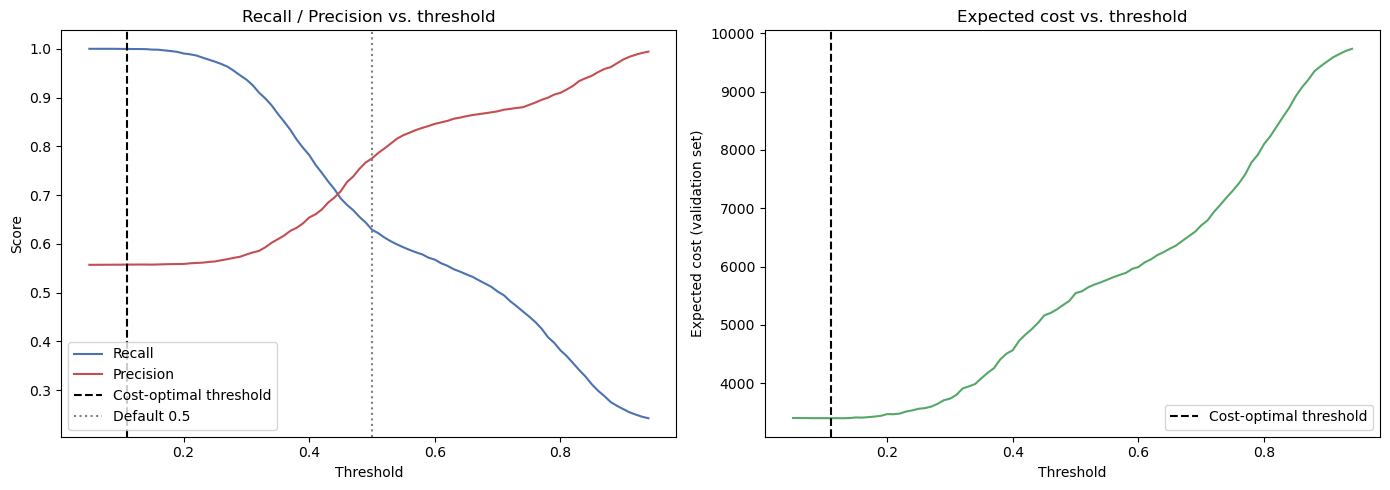

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['threshold'], results_df['recall'], label='Recall', color='#4C72B0')
axes[0].plot(results_df['threshold'], results_df['precision'], label='Precision', color='#C44E52')
axes[0].axvline(best_threshold_row['threshold'], color='black', linestyle='--', label='Cost-optimal threshold')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Default 0.5')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score'); axes[0].legend()
axes[0].set_title('Recall / Precision vs. threshold')

axes[1].plot(results_df['threshold'], results_df['expected_cost'], color='#55A868')
axes[1].axvline(best_threshold_row['threshold'], color='black', linestyle='--', label='Cost-optimal threshold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Expected cost (validation set)'); axes[1].legend()
axes[1].set_title('Expected cost vs. threshold')

plt.tight_layout()
plt.savefig('../../../reports/figures/threshold_tuning.png', dpi=120, bbox_inches='tight')
plt.show()


**What we found:** *(fill in — state the chosen threshold and how much Recall improves compared to the default 0.5, along with the Precision tradeoff. This is likely to move Recall meaningfully higher than any of the default-threshold numbers reported in the model comparison, since the cost ratio explicitly favors catching more late orders.)*


## 3. Save the chosen threshold

In [ ]:
import json
with open('../../../data/processed/chosen_threshold.json', 'w') as f:
    json.dump({
        'threshold': float(best_threshold_row['threshold']),
        'cost_false_negative': COST_FALSE_NEGATIVE,
        'cost_false_positive': COST_FALSE_POSITIVE,
        'validation_recall_at_threshold': float(best_threshold_row['recall']),
        'validation_precision_at_threshold': float(best_threshold_row['precision']),
    }, f, indent=2)
print("Saved chosen threshold.")
